# Data Preparation

In [1]:
import pandas as pd

from src.compare import compare_transformations, compare_skewness, compare_distributions
from src.enums import keys, prefixes
from src.transform import Transformation, transform

aq = pd.read_csv('04-01-open-meteo-2023-2026.csv')
rv = pd.read_csv('04-01-respiratory-virus-dashboard-2023-2026.csv')

## Stabilize air quality data

Further analysis showed that previously stabilized data become skewed again after aggregation. Also, previously extremely skewed columns can now be stabilized with transformations. We are applying stabilization to these columns again.

Features that cannot be stabilized would have been discretized.

### Compare skewness across different transformations

In [2]:
compare_transformations(aq)

,Original,Square root,Log transformation,Cube root,Yeo-Johnson Transform
SEASON,N/A,N/A,N/A,N/A,N/A
WEEKENDING,N/A,N/A,N/A,N/A,N/A
MMWR_WEEK,-0.19,-0.69,-1.25,-0.91,-0.32
MMWR_YEAR,-0.06,-0.06,-0.06,-0.06,-0.03
us_aqi (USAQI),1.54,1.03,0.63,0.88,0.03
us_aqi_pm2_5 (USAQI),0.59,0.16,-0.27,0.01,0.01
us_aqi_pm10 (USAQI),0.71,0.36,0.05,0.24,0.0
us_aqi_nitrogen_dioxide (USAQI),-0.21,-0.47,-0.75,-0.57,-0.19
us_aqi_carbon_monoxide (USAQI),1.0,0.58,0.35,0.45,0.07
us_aqi_ozone (USAQI),2.04,1.39,0.84,1.19,-0.03


### Transform skewed features

In [3]:
transformations = {
    keys['us_aqi_pm2_5 (USAQI)']: Transformation.SQRT,
    keys['us_aqi_pm10 (USAQI)']: Transformation.SQRT,
    keys['us_aqi_sulphur_dioxide (USAQI)']: Transformation.SQRT,
    keys['aerosol_optical_depth ()']: Transformation.SQRT,
    keys['nitrogen_dioxide (μg/m³)']: Transformation.SQRT,
    keys['pm10 (μg/m³)']: Transformation.SQRT,

    keys['us_aqi_carbon_monoxide (USAQI)']: Transformation.LOG1P,
    keys['pm2_5 (μg/m³)']: Transformation.LOG1P,
    keys['carbon_monoxide (μg/m³)']: Transformation.LOG1P,

    keys['us_aqi (USAQI)']: Transformation.YEO_JOHNSON,
    keys['us_aqi_ozone (USAQI)']: Transformation.YEO_JOHNSON,
    keys['dust (μg/m³)']: Transformation.YEO_JOHNSON,
    keys['sulphur_dioxide (μg/m³)']: Transformation.YEO_JOHNSON,
}
aq_transformed = transform(
    aq,
    transformations,
    prefixes['04_01_data_preparation_']
)

### Skewness comparison

In [4]:
compare_skewness(aq, aq_transformed, transformations)

,Transformation,Skewness (Original),Skewness (Transformed)
us_aqi_pm2_5 (USAQI),sqrt,0.59,0.16
us_aqi_pm10 (USAQI),sqrt,0.71,0.36
us_aqi_sulphur_dioxide (USAQI),sqrt,1.37,0.47
aerosol_optical_depth (),sqrt,0.65,0.31
nitrogen_dioxide (μg/m³),sqrt,0.8,0.45
pm10 (μg/m³),sqrt,0.55,0.2
us_aqi_carbon_monoxide (USAQI),log1p,1.0,0.35
pm2_5 (μg/m³),log1p,1.22,0.4
carbon_monoxide (μg/m³),log1p,1.26,0.52
us_aqi (USAQI),yeo-johnson,1.54,0.03


### Distribution comparison

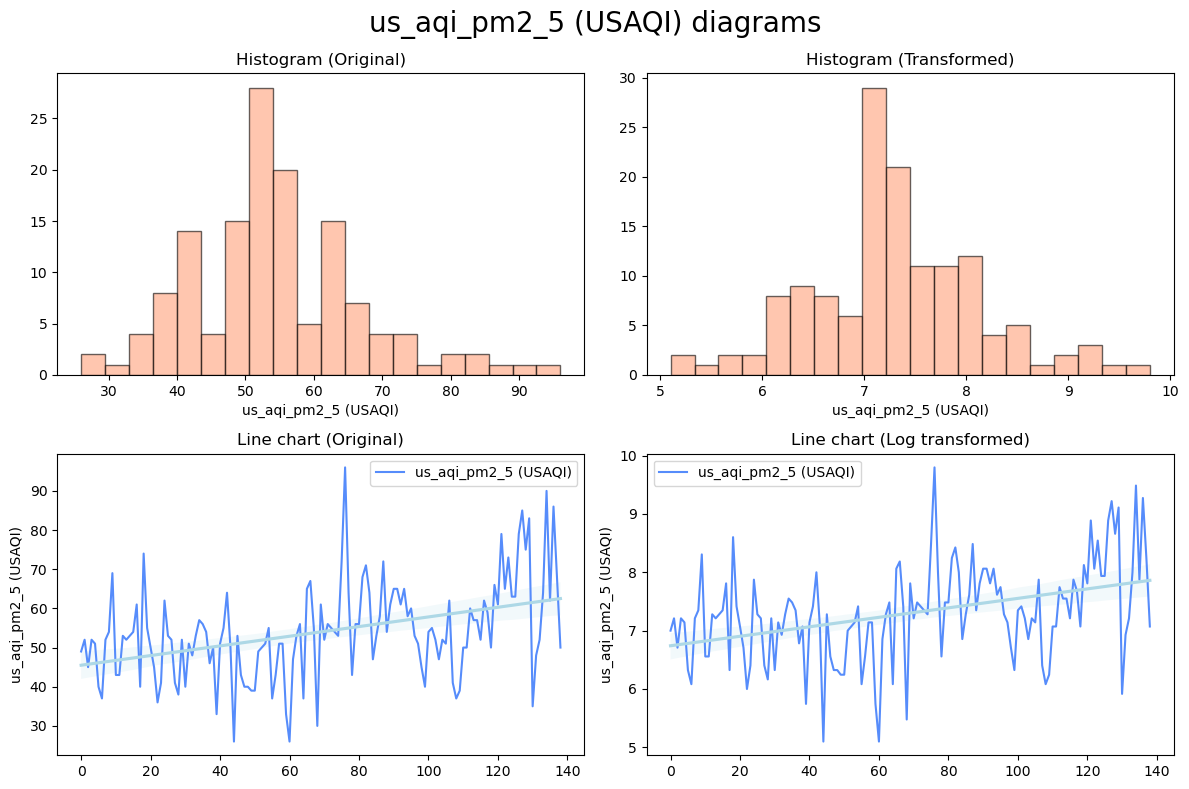

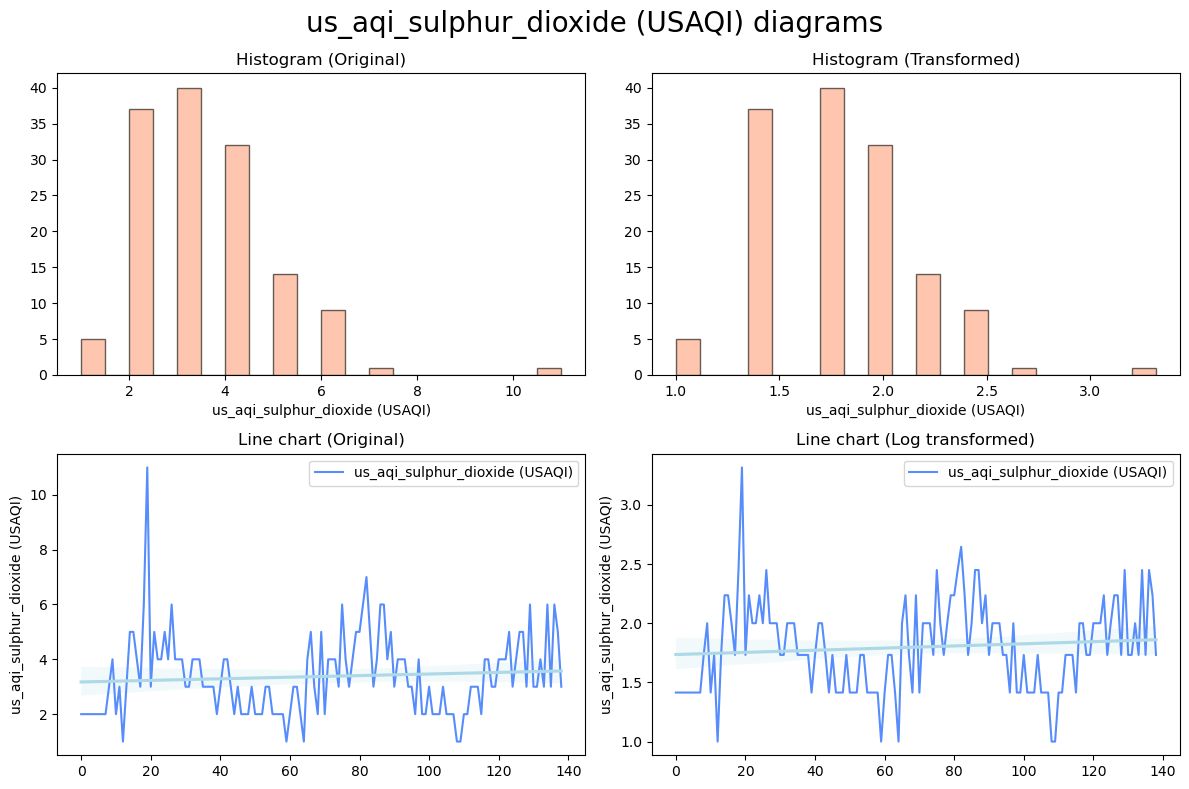

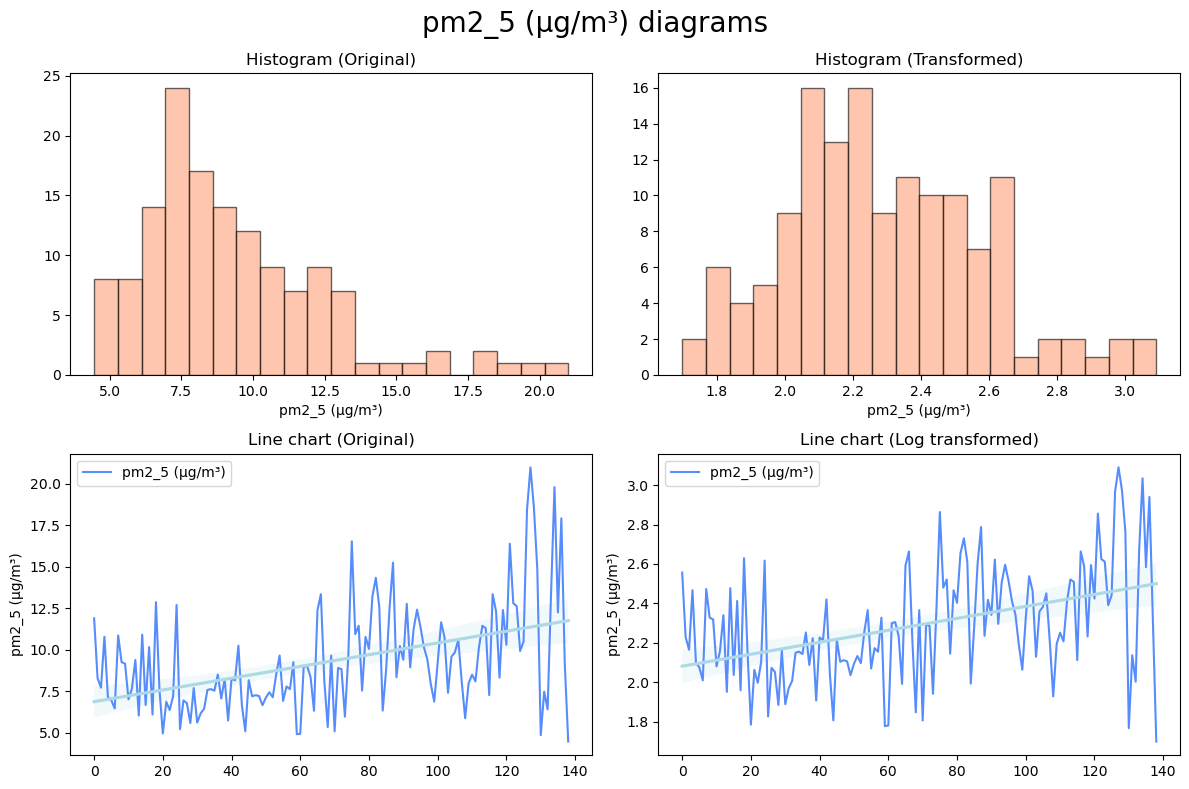

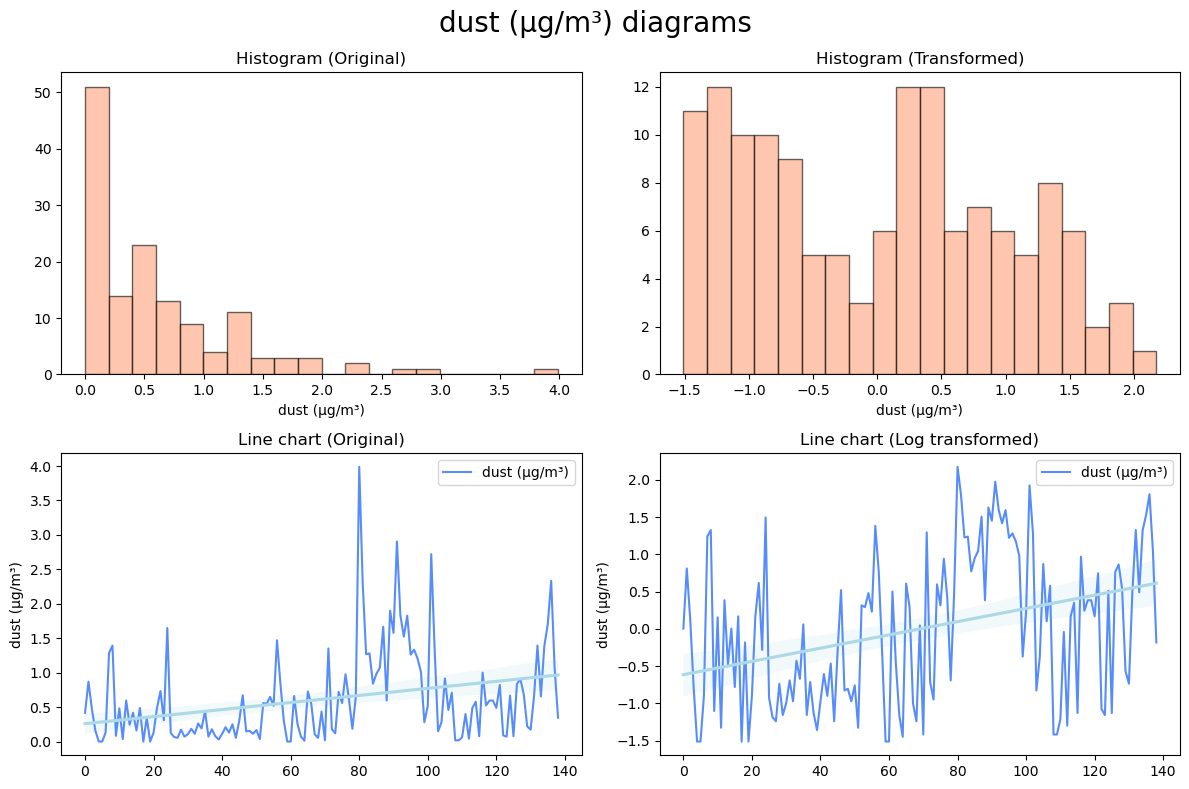

In [6]:
compare_distributions(
    aq,
    aq_transformed,
    [
        keys['us_aqi_pm2_5 (USAQI)'], # square root transformation.
        keys['us_aqi_sulphur_dioxide (USAQI)'], # square root transformation.
        keys['pm2_5 (μg/m³)'], # log transformation.
        keys['dust (μg/m³)'] # Yeo-Johnson transformation.
    ]
)